# Can downsampling the resolution of input images improve performance?

This notebook evaluates the effect of pre-segmentation image downsampling on pipeline run speed and recognition accuracy. Specifically, it will show that this technique leads to modest speed increases at little to no cost to accuracy. Accuracy here is measured by Hamming distance from a test image taken from the same subject. Images are taken from the CASIA Iris Thousand dataset, which can be downloaded here: https://www.kaggle.com/datasets/sondosaabed/casia-iris-thousand.

## Imports

In [1]:
import cv2
import iris
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os
from pathlib import Path
from tqdm import tqdm
from itertools import combinations
import random
from PIL import Image

## Setup

Modify the dataset_path variable to point to the directory containing CASIA data. This should be a directory called CASIA-Iris-Thousand

In [2]:
dataset_path = "/Users/calvindejong/Downloads/archive/CASIA-Iris-Thousand/" 

## Effect of pre-segmentation image downsampling on IrisPipeline execution speed

In [3]:
img_path = dataset_path + "CASIA-Iris-Thousand/000/L/S5000L00.jpg"
test_path = dataset_path + "CASIA-Iris-Thousand/000/L/S5000L06.jpg"
img = Image.open(img_path)
test_img = Image.open(test_path)

In [4]:
def get_execution_time(img_pixels):
    ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")
    pipeline = iris.IRISPipeline()
    start_time = time.perf_counter()
    
    output = pipeline(ir_image)
    
    end_time = time.perf_counter()
    return end_time - start_time

In [5]:
downsampling_ratios = [0.1 * x for x in range(10, 31)] # 1.0 to 3.0
execution_times = []

for ratio in downsampling_ratios:
    downsampled = img.resize((int(img.size[0] // ratio), int(img.size[1] // ratio)), resample=Image.LANCZOS) # uses the Lanczos algorithm
    grey_img = downsampled.convert('L')
    img_pixels = np.array(grey_img)

    exe_time = get_execution_time(img_pixels)
    execution_times.append(exe_time)


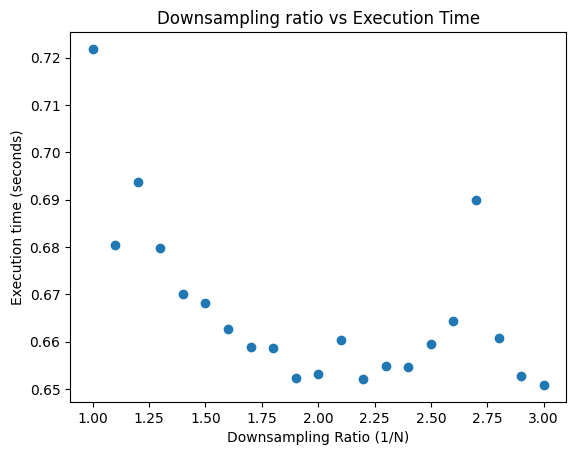

In [6]:
plt.scatter(downsampling_ratios, execution_times, marker='o')
plt.title('Downsampling ratio vs Execution Time')
plt.xlabel('Downsampling Ratio (1/N)')
plt.ylabel('Execution time (seconds)')
plt.show()

Execution time is to a certain extent unpredictable, but consistent runtime decreases of 3-4% can be observed when the width and height of the input image are decreased by a factor greater than 2

# Effect of pre-segmentation image downsampling on recognition accuracy (CASIA dataset)

It remains to be seen whether the loss of information resulting from downsampling input images affects recognition accuracy. The following code shows that as long as the downsampling ratio is not excessively high, accuracy is not meaningfully decreased.

In [7]:
def calc_template(img_pixels):
    iris_pipeline = iris.IRISPipeline()
    output = iris_pipeline(
        iris.IRImage(
            img_data=img_pixels,
            image_id=os.path.basename(img_path),
            eye_side='left'
        )
    )
    return output["iris_template"] 

In [8]:
test_template = calc_template(np.array(test_img))
matcher = iris.HammingDistanceMatcher()
downsampling_ratios = [0.1 * x for x in range(10, 41)] # 1.0 to 3.0
ham_distances = {}
for ratio in downsampling_ratios:
    downsampled = img.resize((int(img.size[0] // ratio), int(img.size[1] // ratio)), resample=Image.LANCZOS)
    grey_img = downsampled.convert('L')
    img_pixels = np.array(grey_img)
    template = calc_template(img_pixels)
    if template is not None:  
        ham_distance = matcher.run(template, test_template)
        ham_distances[ratio] = ham_distance

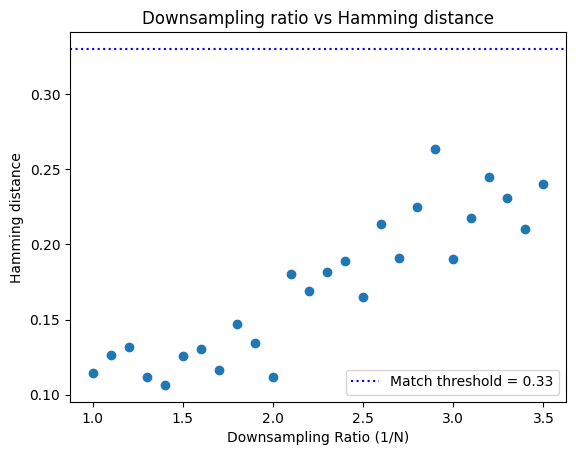

In [9]:
plt.scatter(ham_distances.keys(), ham_distances.values())
plt.title("Downsampling ratio vs Hamming distance")
plt.axhline(y=0.33, color='blue', linestyle=':', label='Match threshold = 0.33')
plt.xlabel('Downsampling Ratio (1/N)')
plt.ylabel('Hamming distance')
plt.legend()
plt.show()

Conclusion: Significant loss of information leading to lower recognition accuracy is not seen on CASIA dataset images (640x480 pixels) until the image is downsampled by a factor greater than 3.5. Thus, if computational performance is a high priority, one can downsample images prior to inference without appreciably sacrificing accuracy.